<a href="https://colab.research.google.com/github/Ravindra1972/Anaytics-in-finance-using-Python/blob/main/Quant_Analysis_of_Stock_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import matplotlib.pyplot as plt; plt.rcdefaults()
import pandas as pd

import warnings
warnings.filterwarnings("ignore")

# yfinance is used to fetch data
!pip install yfinance pandas_datareader
import yfinance as yf
import pandas_datareader as pdr

In [5]:
# input
symbol = 'AMD'
start = '2007-01-01'
end = '2026-07-01'

# Read data
dataset = yf.download(symbol,start,end)

# View Data
dataset.head()
dataset.tail()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AMD,AMD,AMD,AMD,AMD
Date,,,,,
2026-06-24,519.739990,524.960022,503.500000,520.820007,26548300
2026-06-25,532.570007,550.880005,507.000000,543.929993,27031300
2026-06-26,521.580017,525.109985,502.609985,519.799988,52705100
2026-06-29,539.489990,542.190002,495.350006,522.840027,26671000
2026-06-30,580.909973,584.729980,545.570007,545.570007,34488500


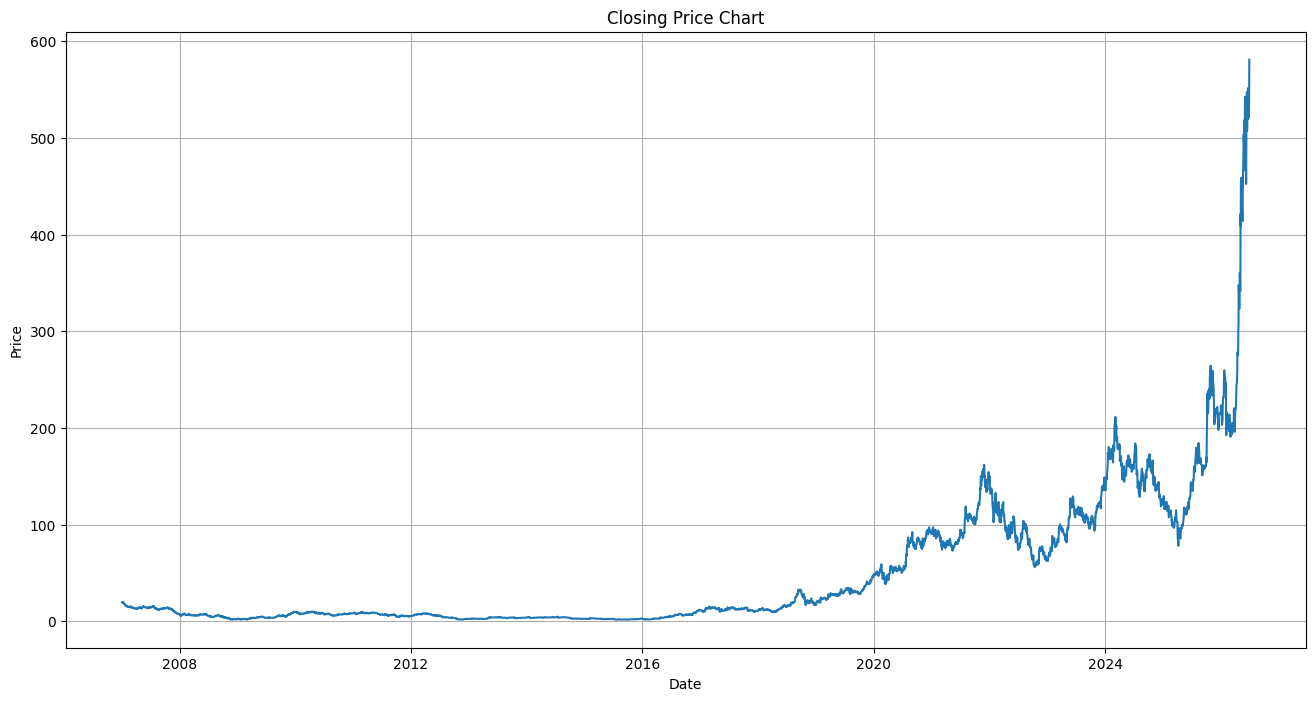

In [7]:
import matplotlib.pyplot as plt
plt.figure(figsize=(16,8))
plt.plot(dataset['Close'])
plt.title('Closing Price Chart')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True)
plt.show()

In [ ]:
monthly = dataset.asfreq('BM')
monthly['Returns'] = dataset['Adj Close'].pct_change().dropna()
monthly.head()



In [9]:
monthly = dataset.asfreq('BM')
monthly['Returns'] = dataset['Close'].pct_change().dropna()
monthly.head()
monthly.tail()

Price,Close,High,Low,Open,Volume,Returns
Ticker,AMD,AMD,AMD,AMD,AMD,
Date,,,,,,
2026-02-27,200.210007,201.889999,197.740005,200.110001,31312400.0,-0.017036
2026-03-31,203.429993,204.000000,196.410004,198.050003,42318700.0,0.037696
2026-04-30,354.489990,354.959991,332.600006,341.359985,42115300.0,0.051556
2026-05-29,516.099976,522.000000,503.429993,520.799988,30803200.0,-0.003841
2026-06-30,580.909973,584.729980,545.570007,545.570007,34488500.0,0.076776


In [10]:
monthly['Month_Name'] = monthly.index.strftime("%b")
monthly['Month_Name_Year'] = monthly.index.strftime("%b-%Y")

In [11]:
import calendar
import datetime

monthly = monthly.reset_index()
monthly['Month'] = monthly["Date"].dt.month
monthly.tail()

Price,Date,Close,High,Low,Open,Volume,Returns,Month_Name,Month_Name_Year,Month
Ticker,,AMD,AMD,AMD,AMD,AMD,,,,
229,2026-02-27,200.210007,201.889999,197.740005,200.110001,31312400.0,-0.017036,Feb,Feb-2026,2
230,2026-03-31,203.429993,204.000000,196.410004,198.050003,42318700.0,0.037696,Mar,Mar-2026,3
231,2026-04-30,354.489990,354.959991,332.600006,341.359985,42115300.0,0.051556,Apr,Apr-2026,4
232,2026-05-29,516.099976,522.000000,503.429993,520.799988,30803200.0,-0.003841,May,May-2026,5
233,2026-06-30,580.909973,584.729980,545.570007,545.570007,34488500.0,0.076776,Jun,Jun-2026,6


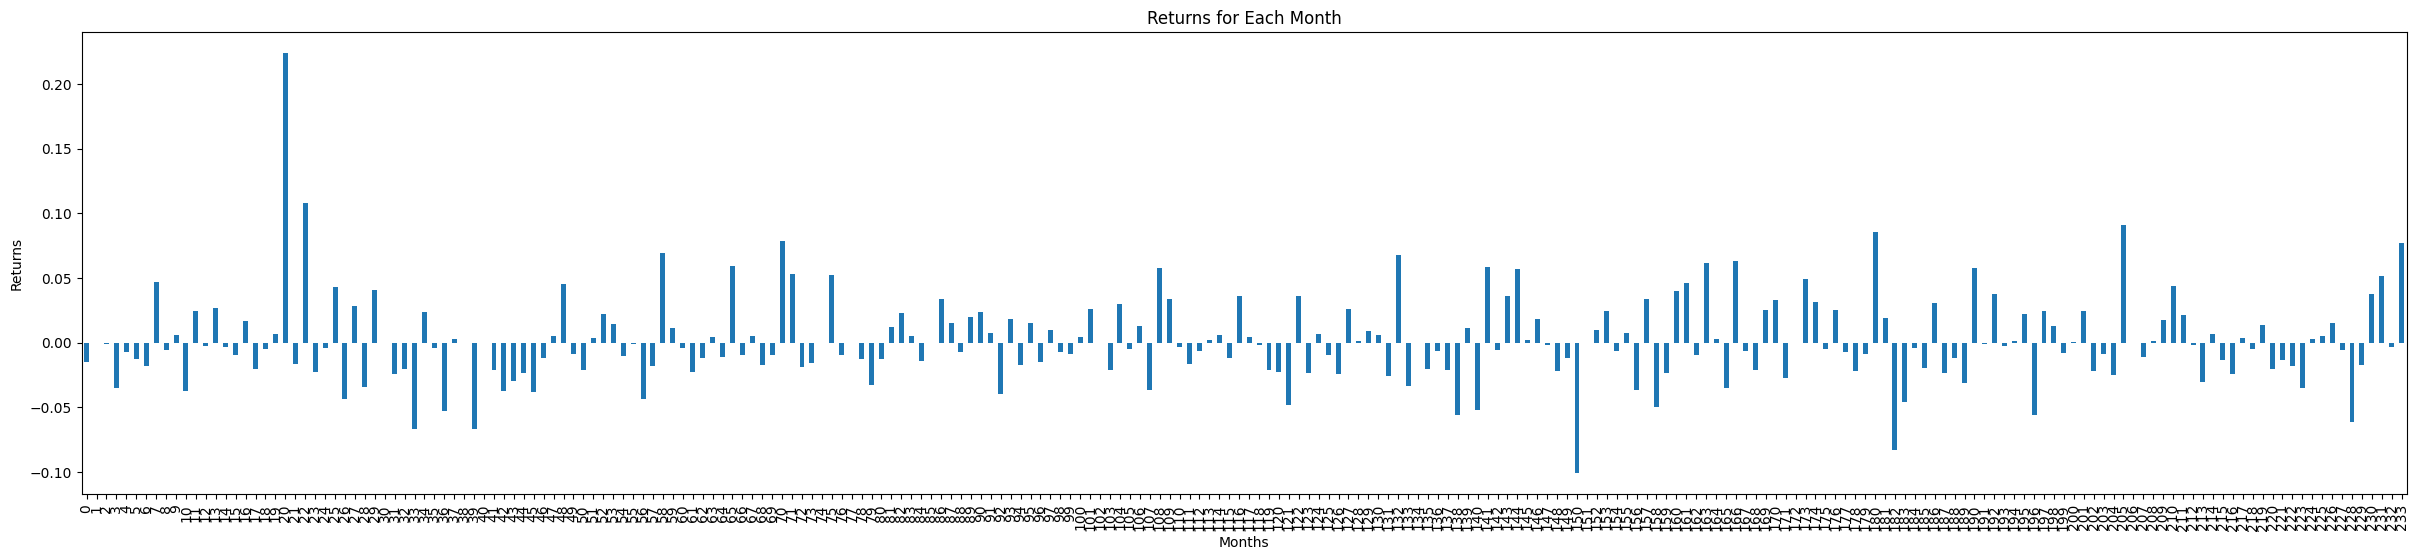

In [12]:
monthly['Returns'].plot(kind='bar', figsize=(30,6))
plt.xlabel("Months")
plt.ylabel("Returns")
plt.title("Returns for Each Month")
plt.show()

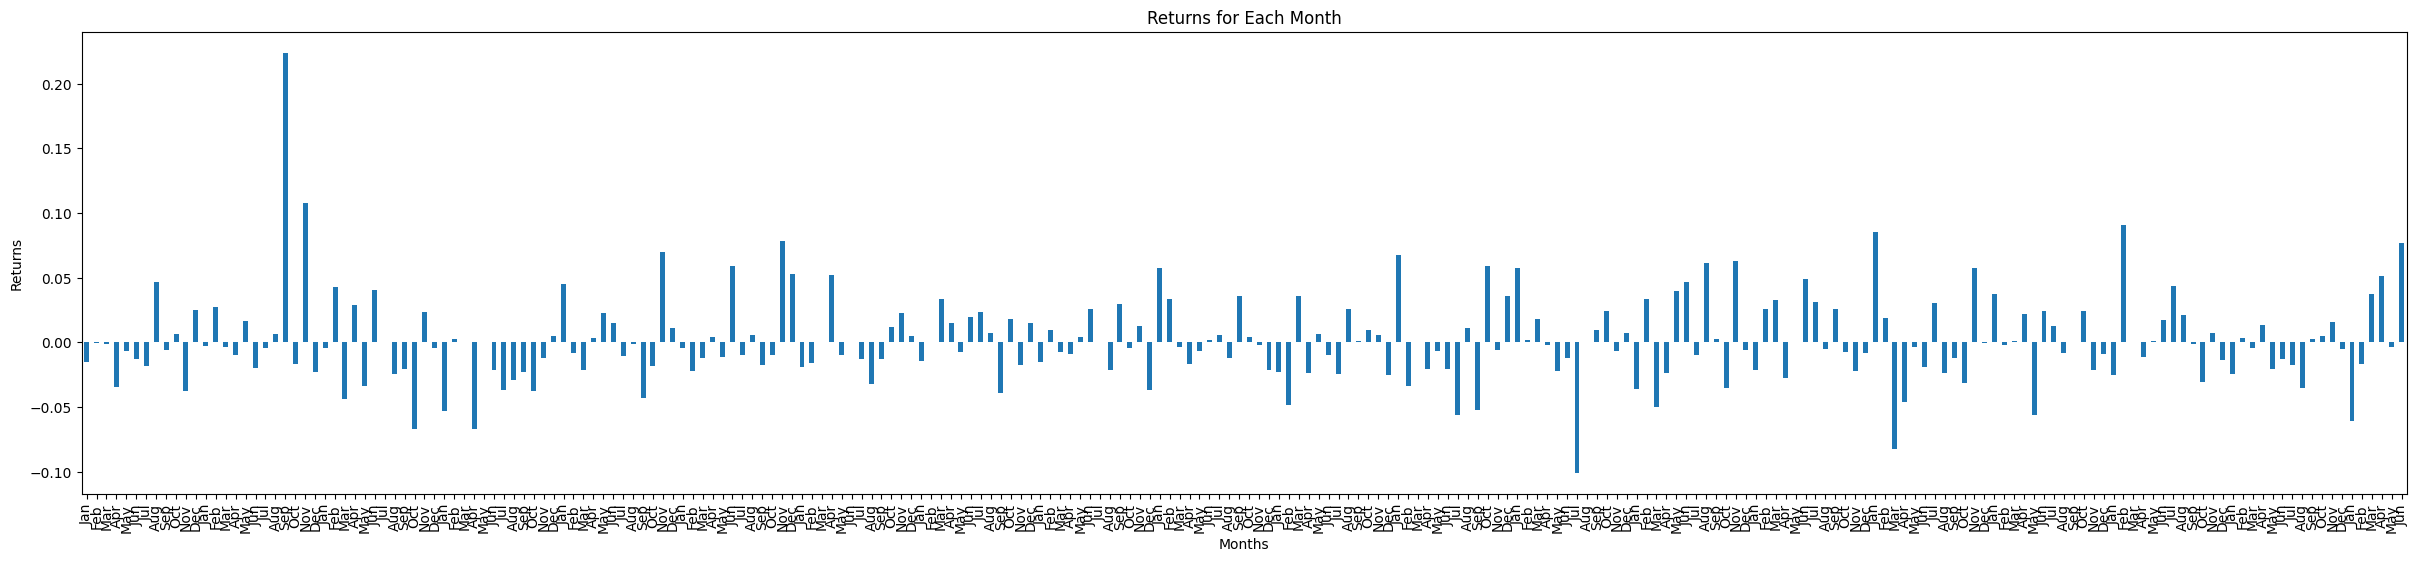

In [13]:
monthly['Returns'].plot(kind='bar', figsize=(30,6))
plt.xlabel("Months")
plt.ylabel("Returns")
plt.title("Returns for Each Month")
plt.xticks(monthly.index, monthly['Month_Name'])
plt.show()

In [14]:
from matplotlib import dates as mdates
import datetime as dt

monthly['ReturnsPositive'] = 0 < monthly['Returns']
monthly['Date'] = pd.to_datetime(monthly['Date'])
monthly['Date'] = monthly['Date'].apply(mdates.date2num)

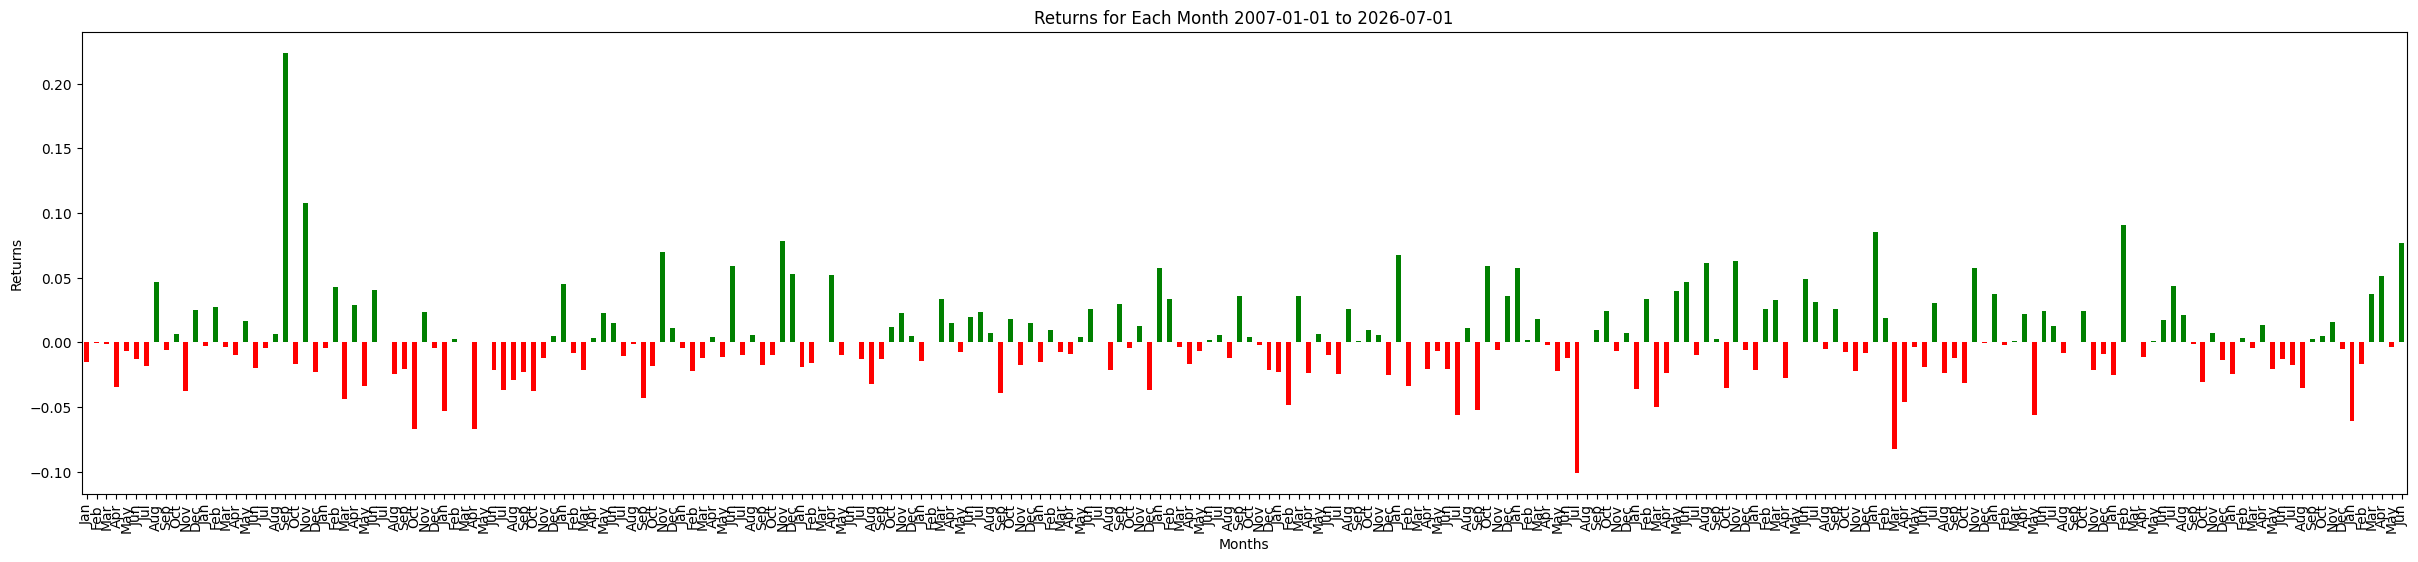

In [15]:
colors = monthly.ReturnsPositive.map({True: 'g', False: 'r'})
monthly['Returns'].plot(kind='bar', color = colors, figsize=(30,6))
plt.xlabel("Months")
plt.ylabel("Returns")
plt.title("Returns for Each Month " + start + ' to ' + end)
plt.xticks(monthly.index, monthly['Month_Name'])
plt.show()

In [17]:
yearly = dataset.asfreq('BY')
yearly['Returns'] = dataset['Close'].pct_change().dropna()
yearly

Price,Close,High,Low,Open,Volume,Returns
Ticker,AMD,AMD,AMD,AMD,AMD,
Date,,,,,,
2007-12-31,7.500000,7.600000,7.260000,7.260000,19668800,0.024590
2008-12-31,2.160000,2.200000,2.110000,2.200000,10226500,-0.022624
2009-12-31,9.680000,9.770000,9.630000,9.750000,9396500,-0.004115
2010-12-31,8.180000,8.190000,8.050000,8.140000,7971200,0.004914
2011-12-30,5.400000,5.450000,5.280000,5.340000,6906000,0.011236
2012-12-31,2.400000,2.420000,2.280000,2.290000,20698200,0.052632
2013-12-31,3.870000,3.880000,3.830000,3.870000,12347800,0.005195
2014-12-31,2.670000,2.700000,2.640000,2.640000,11177900,0.015209


In [18]:
yearly = yearly.reset_index()
yearly

Price,Date,Close,High,Low,Open,Volume,Returns
Ticker,,AMD,AMD,AMD,AMD,AMD,
0,2007-12-31,7.500000,7.600000,7.260000,7.260000,19668800,0.024590
1,2008-12-31,2.160000,2.200000,2.110000,2.200000,10226500,-0.022624
2,2009-12-31,9.680000,9.770000,9.630000,9.750000,9396500,-0.004115
3,2010-12-31,8.180000,8.190000,8.050000,8.140000,7971200,0.004914
4,2011-12-30,5.400000,5.450000,5.280000,5.340000,6906000,0.011236
5,2012-12-31,2.400000,2.420000,2.280000,2.290000,20698200,0.052632
6,2013-12-31,3.870000,3.880000,3.830000,3.870000,12347800,0.005195
7,2014-12-31,2.670000,2.700000,2.640000,2.640000,11177900,0.015209
8,2015-12-31,2.870000,3.010000,2.870000,2.970000,11086100,-0.036913
